In [299]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [300]:
import math

def show(crops, figsize=None, ncols=2, cmap=None):
    crops = list(crops)
    rows = math.ceil(len(crops) / ncols)
    if figsize is None:
        figsize = (10 * rows, 10 * rows)
        print("figsize", figsize)
    _, axs = plt.subplots(rows, ncols, figsize=figsize)
    try:
        axs[0]
        axs = axs.flatten()
    except:
        axs = [axs]

    for i, c in enumerate(crops):
        if cmap is None:
            axs[i].imshow(c)
        else:
            axs[i].imshow(c, cmap=cmap)
    plt.tight_layout()
    plt.show()

# Transform an image to log scale

A log graph would have a larger value for smaller inputs. It platues after one point. It essentially increases the range of black pixels, while decreasing the range of white pixels

In [301]:
dark = Path.home() / "Downloads" / "dark-image.jpg"
dark = plt.imread(dark)
dark_gray = cv2.cvtColor(dark, cv2.COLOR_RGB2GRAY)
dark_gray_float = dark_gray.astype(np.float32)

In [302]:
log = np.log(dark_gray_float + 1)

In [303]:
255 / np.max(log)

np.float32(45.985905)

figsize (10, 10)


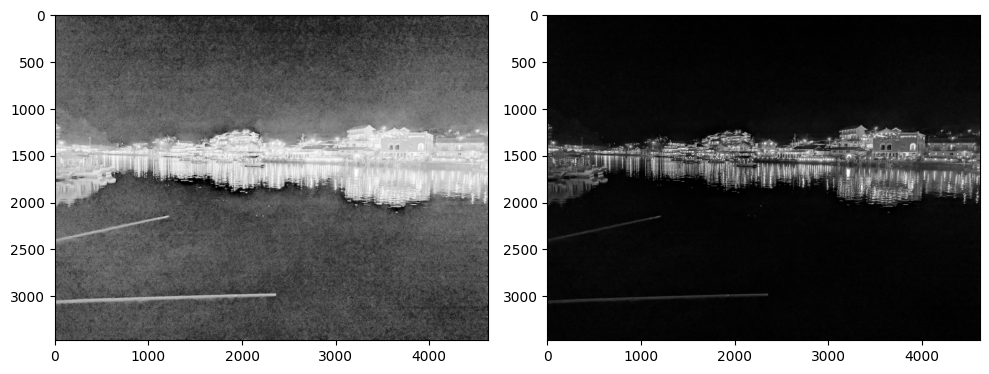

In [304]:
scaled = log * 45
scaled = np.floor(scaled)
scaled = np.clip(scaled, 0, 255).astype(np.uint8)

show([scaled, dark_gray], cmap="gray")

# Histogram equalisation

I'm going to confirm where equalisation can turn bad

Hypothesis:
- If there are a huge number of black pixels—say, a starry night sky—the black pixels would be converted to slightly gray pixels, making the image flatter. This is the case where contrast was useful, but we removed it by using equalization. 
- I feel the equalization can sometimes result in unnecessary noise being amplified. You could have, let's say, a bunch of gray pixels with a value of 123 and just four or five pixels of 124 or 125, which are roughly the same as 123, and they would shoot up. I need to verify this.  

figsize (10, 10)


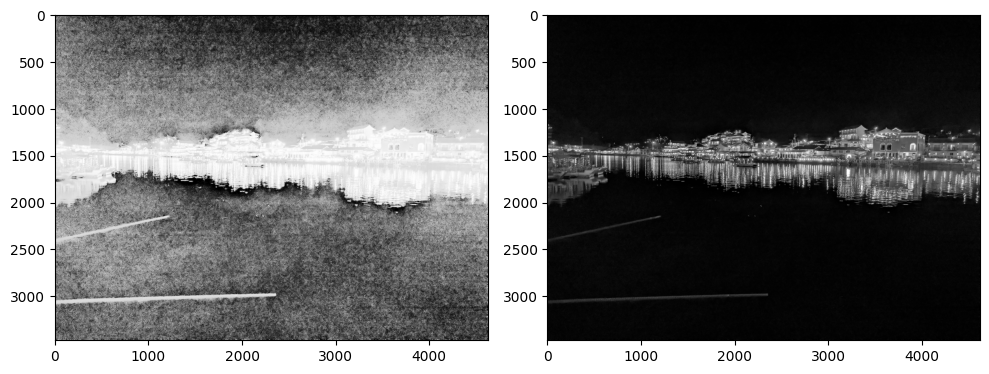

In [20]:
equ = cv2.equalizeHist(dark_gray)
show([equ, dark_gray], cmap="gray")

figsize (10, 10)


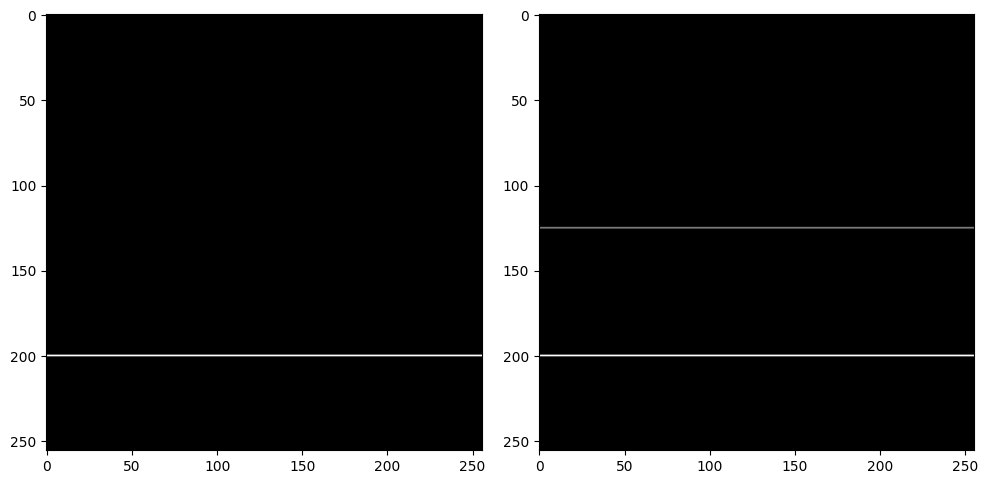

In [35]:
img = np.zeros((256, 256), dtype=np.uint8)
img[125].fill(1)
img[200].fill(200)



# equalise increases the intensity of the pixel line of value 1 to a higher value which is now visible
show([img, cv2.equalizeHist(img)], cmap="gray")

## Where is it useful?

I think the pixel intensity shouldn't change a lot unnecessarily. You should have a smooth gradient across the whole image. In that case, just stretch the gradient a bit and increase the band of values being used. 

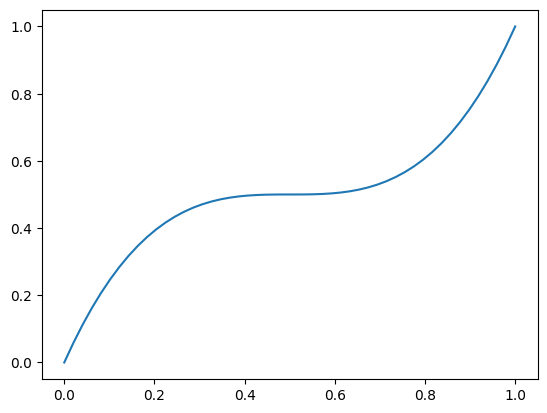

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# i get the upward going curve when x is pos
# i get downward going when x is neg
# ive figured out how to do halfway
# how do i do when the point of inflection is not halfway?

R_ONE_SIDE = 2
K = 3

xs = np.linspace(0, 1)
ys = (((2*xs-1)**3) + 1) / 2
plt.plot(xs, ys)
plt.show()

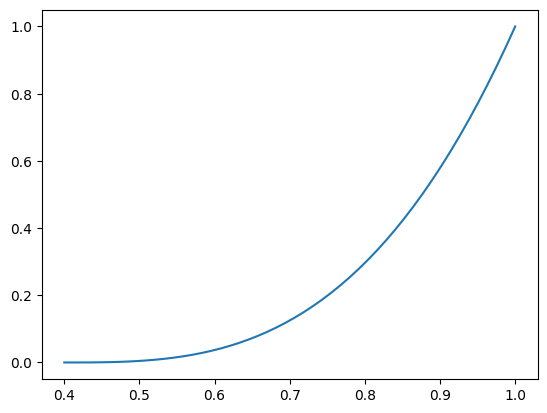

In [ ]:
# this is the range that gives me a good range
# my initial range is 0.4
# then i need to scale my x. 1 / 0.4

midpoint = 0.4


# i have points from 0.4 to 1 (a range of 0.6)
# x ranges from 0.4 to 1 (so 0 -> 0.6)
# 0 -> 0.4
# negative: 0 -> -0.4
xs = np.linspace(0.4, 1)
zs = ((xs - 0.4) / 0.6)**3
plt.plot(xs, zs)
plt.show()

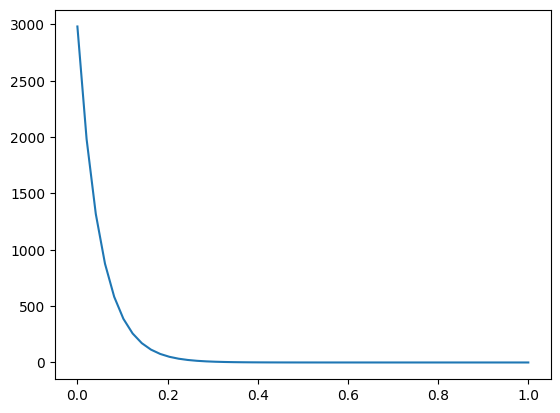

In [202]:
xs = np.linspace(0, 1)
plt.plot(xs, np.exp(-20 * (xs - 0.4)))

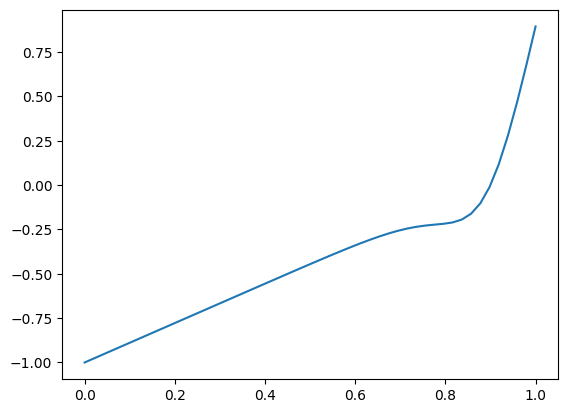

In [ ]:
import math
# i can basically use sigmoid to approximate two linear functions meeting at k



def sigmoid(x):
    return 1 / (1 + math.exp(-20*x))

def slope(x, K):
    return sigmoid(x - K) * (1/(1-K)) + (1 - sigmoid(x - K)) * 1/(K)

# multiplier is (1-K) for x > K, else K
# x - K -> negative -> sigmoid = 0 -> 

K = 0.9
ys = []
xs = np.linspace(0, 1)
for x in xs:
    ys.append(slope(x, K) * (x-K))

plt.plot(xs, ys)
plt.show()

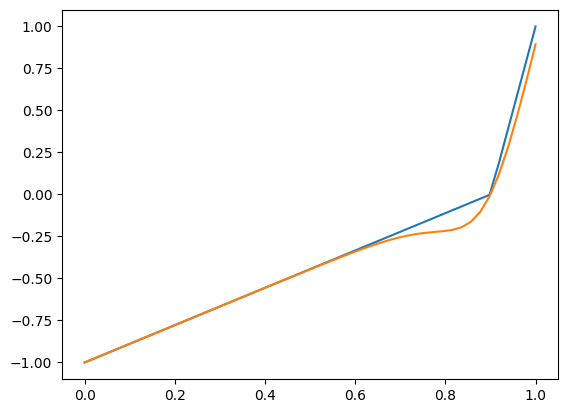

In [197]:
# if greater than k, we want to divide by k
# else we want to divide by 1-k
# how can i make this a continuous function?
# this is how my x looks, which im exponentiating 
# it kinda looks like an exponential function itself

K = 0.9

def smooth_centered_scale(xs, K, alpha=20):
    s = 1 / (1 + np.exp(-alpha * (xs - K)))
    slope = (1/K)*(1 - s) + (1/(1-K))*s
    return (xs - K) * slope

xs = np.linspace(0, 1)
zs = []
for x in xs:
    if x > K:
        zs.append((x - K) / (1-K))
    else:
        zs.append((x-K) / K)
plt.plot(xs, zs)
plt.plot(xs, smooth_centered_scale(xs, K))
plt.show()

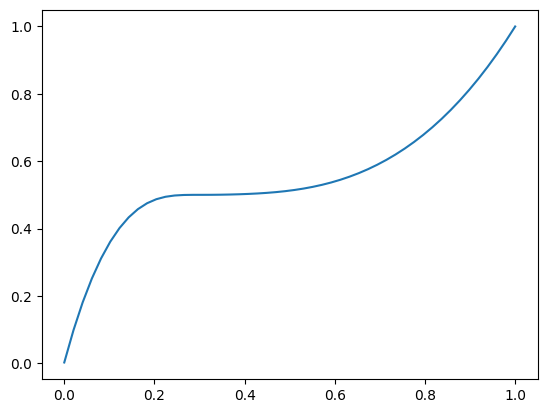

In [201]:
# this function is quite complicated
# and clearly its not the ideal one as well
# for lesser K, it turns into a simple curve instead of an S
# in the smaller range, we want it to curve more

K = 0.3
xs = np.linspace(0, 1)
ys = smooth_centered_scale(xs, K)
# xs = xs ** 3
zs = []
den = 2

for x in ys:
    val = x
    # if x > K:
    #     val = (x - K) / (1-K)
    # else:
    #     val = (x - K) / (K)
    zs.append((val ** 3 + 1) / den)

plt.plot(xs, zs)
plt.show()

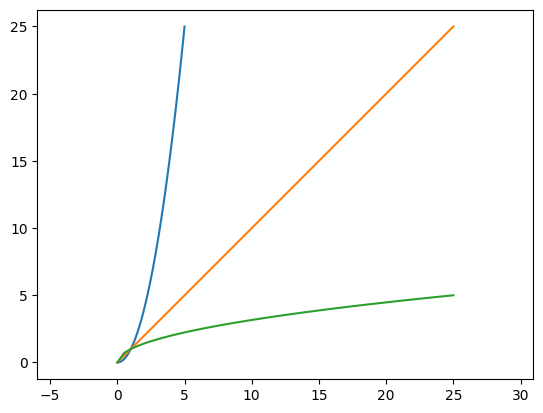

In [257]:
xs = np.linspace(0, 5)

plt.axis('equal')
plt.plot(xs, (xs**2))

zs = np.linspace(0, 25)
plt.plot(zs, zs)
# plt.plot(xs, -xs + 1)
plt.plot(zs, np.sqrt(zs))
plt.show()

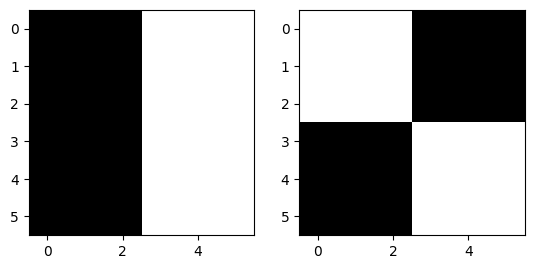

In [294]:
# 3x3 + 3x3 + 3x3 + 3x3
# 6x6

checkered = np.zeros((6,6), dtype=np.uint8)
halves = np.zeros((6,6), dtype=np.uint8)

halves[:, 3:].fill(255)

checkered[:3, :3].fill(255)
checkered[3:, 3:].fill(255)
_, ax = plt.subplots(1, 2)
ax[0].imshow(halves, cmap="gray")
ax[1].imshow(checkered, cmap="gray")

plt.show()

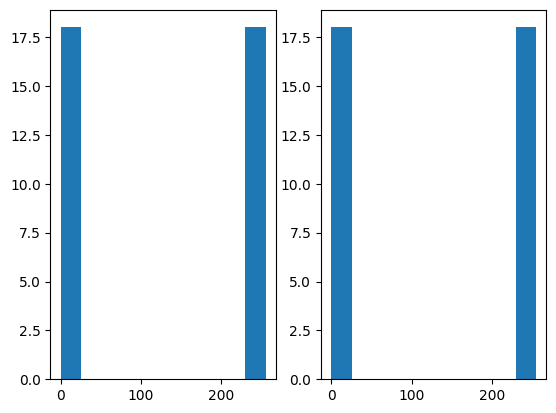

In [295]:
# similar hists
_, ax = plt.subplots(1, 2)
ax[0].hist(halves.flatten())
ax[1].hist(checkered.flatten())
plt.show()

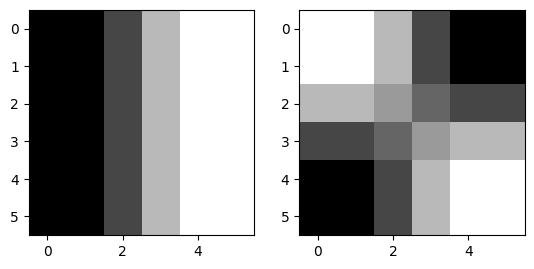

In [ ]:
import cv2

halves_blur = cv2.GaussianBlur(halves, (3,3), 1)
checkered_blur = cv2.GaussianBlur(checkered, (3,3), 1)

_, ax = plt.subplots(1, 2)

ax[0].imshow(halves_blur, cmap="gray")
ax[1].imshow(checkered_blur, cmap="gray")
plt.show()

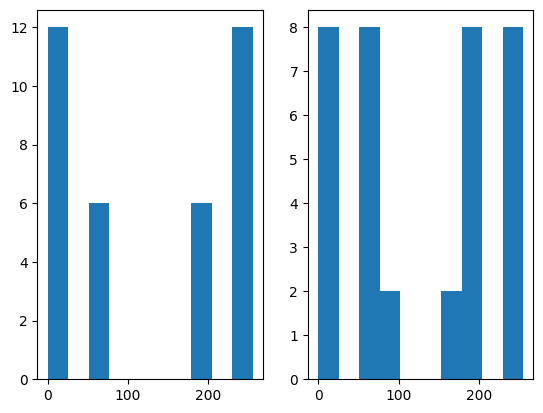

In [297]:
_, ax = plt.subplots(1, 2)
ax[0].hist(halves_blur.flatten())
ax[1].hist(checkered_blur.flatten())
plt.show()

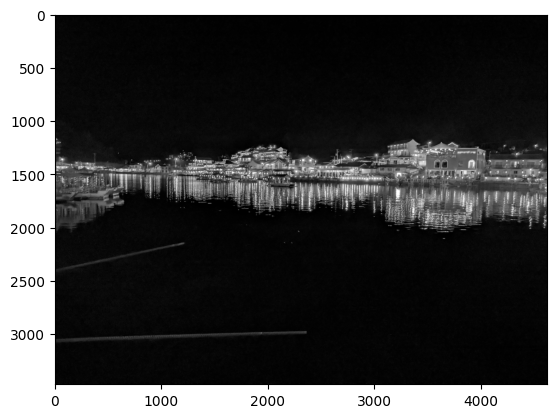

In [311]:
dark = Path.home() / "Downloads" / "dark-image.jpg"
dark = plt.imread(dark)
dark_gray = cv2.cvtColor(dark, cv2.COLOR_RGB2GRAY)
plt.imshow(dark_gray, cmap="gray")

In [324]:
img = cv2.cvtColor(dark, cv2.COLOR_RGB2GRAY).astype(np.float64) / 255.0
for i in tqdm(range(500)):
    img = cv2.GaussianBlur(img, (3,3), 1)

100%|██████████| 500/500 [00:12<00:00, 40.33it/s]


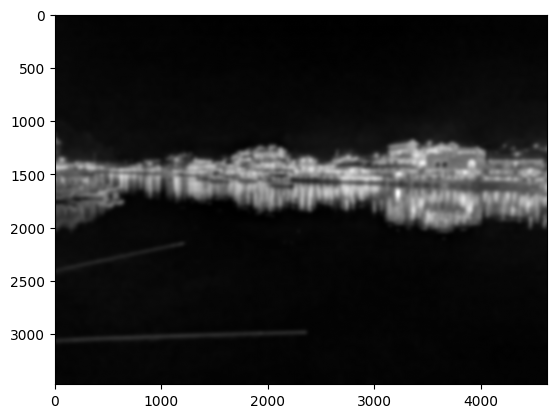

In [326]:
plt.imshow(img, cmap="gray")

100%|██████████| 5000/5000 [00:10<00:00, 463.72it/s]


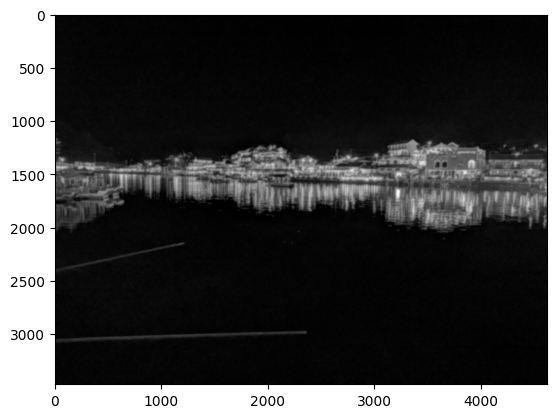

In [320]:

from tqdm import tqdm
for _ in tqdm(range(5000)):
    dark_gray = cv2.GaussianBlur(dark_gray, (3,3), 1)
plt.imshow(dark_gray, cmap="gray")

100%|██████████| 5000/5000 [00:10<00:00, 471.31it/s]


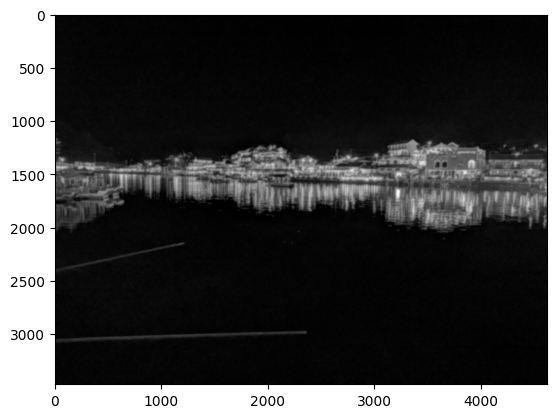

In [319]:
from tqdm import tqdm
for _ in tqdm(range(5000)):
    dark_gray = cv2.GaussianBlur(dark_gray, (3,3), 1)
plt.imshow(dark_gray, cmap="gray")

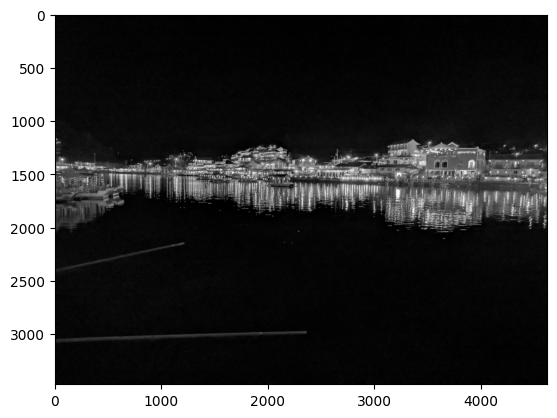

In [ ]:
dark_gray = cv2.GaussianBlur(dark_gray, (3,3), 1)
plt.imshow(dark_gray, cmap="gray")

In [378]:
img = np.zeros((120, 200), dtype=np.uint8)
img.fill(255)


i = 0
while True:
    l, u = i, i+5
    if u >= img.shape[1]:
        break
    img[10:110, l:u].fill(0)
    i = u+20

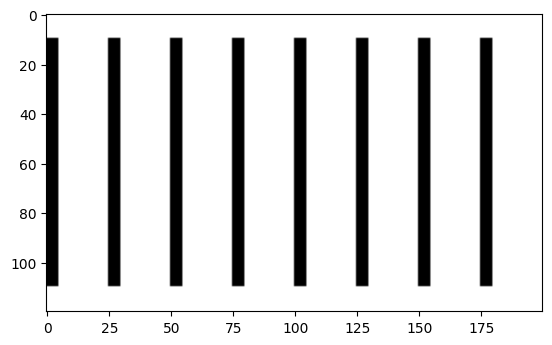

In [379]:
plt.imshow(img, cmap="gray")

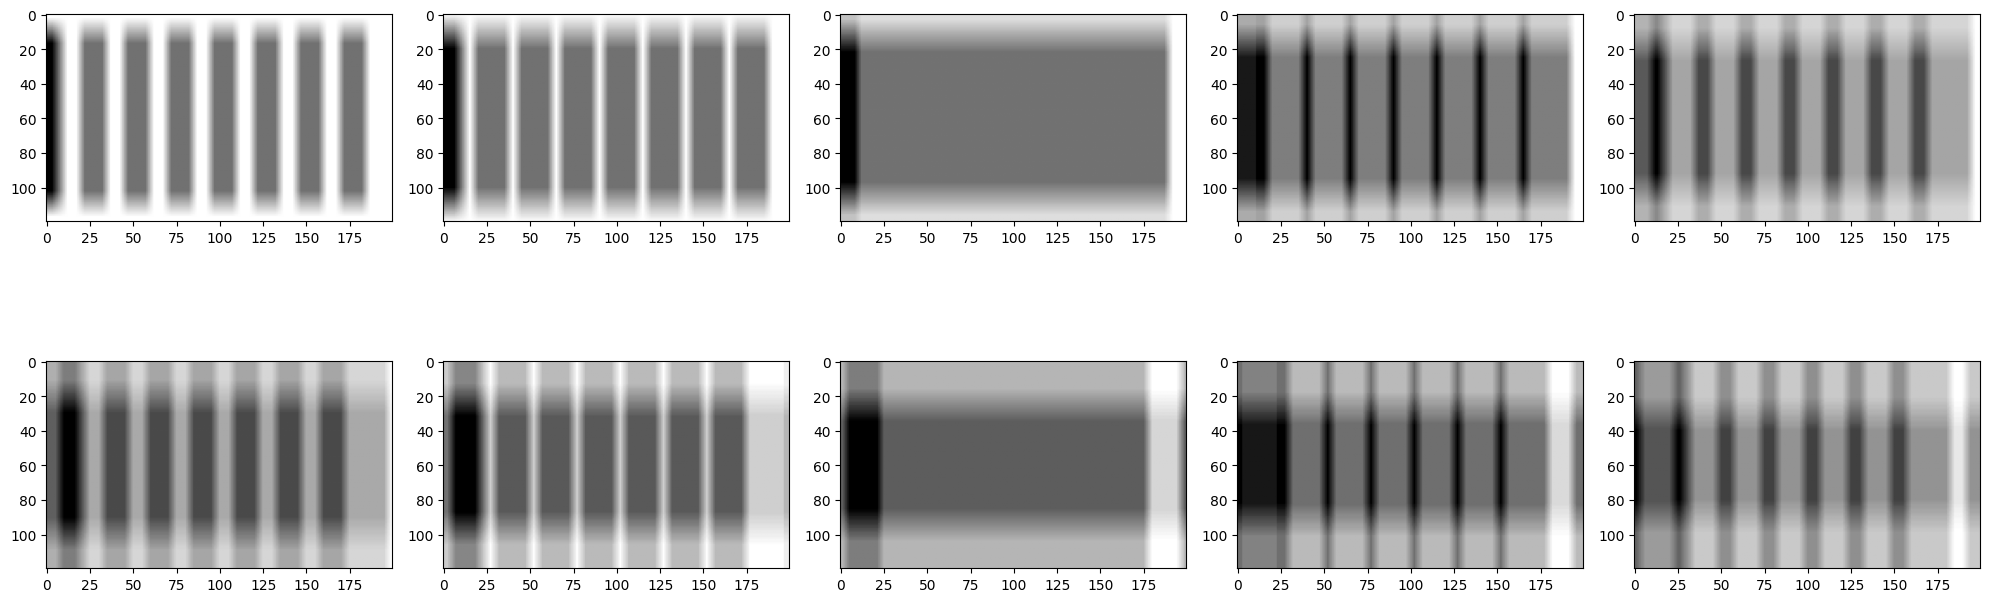

In [384]:
K = 35

def _blur(k):
    return cv2.blur(img, (k,k))

def _ims(ax, img):
    ax.imshow(img, cmap="gray")

_, axs = plt.subplots(2, 5, figsize=(20,8))
axs = axs.flatten()
for i in range(len(axs)):
    _ims(axs[i], _blur(15 + i*5))
plt.tight_layout()
plt.show()

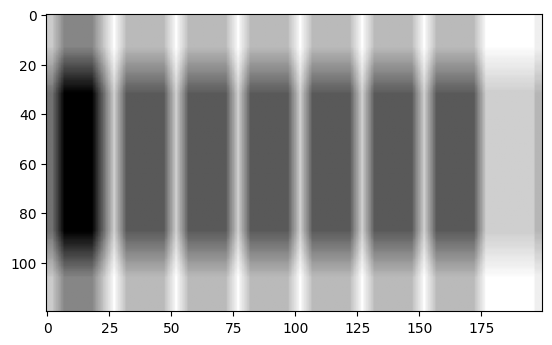

In [400]:
plt.imshow(_blur(45), cmap="gray")

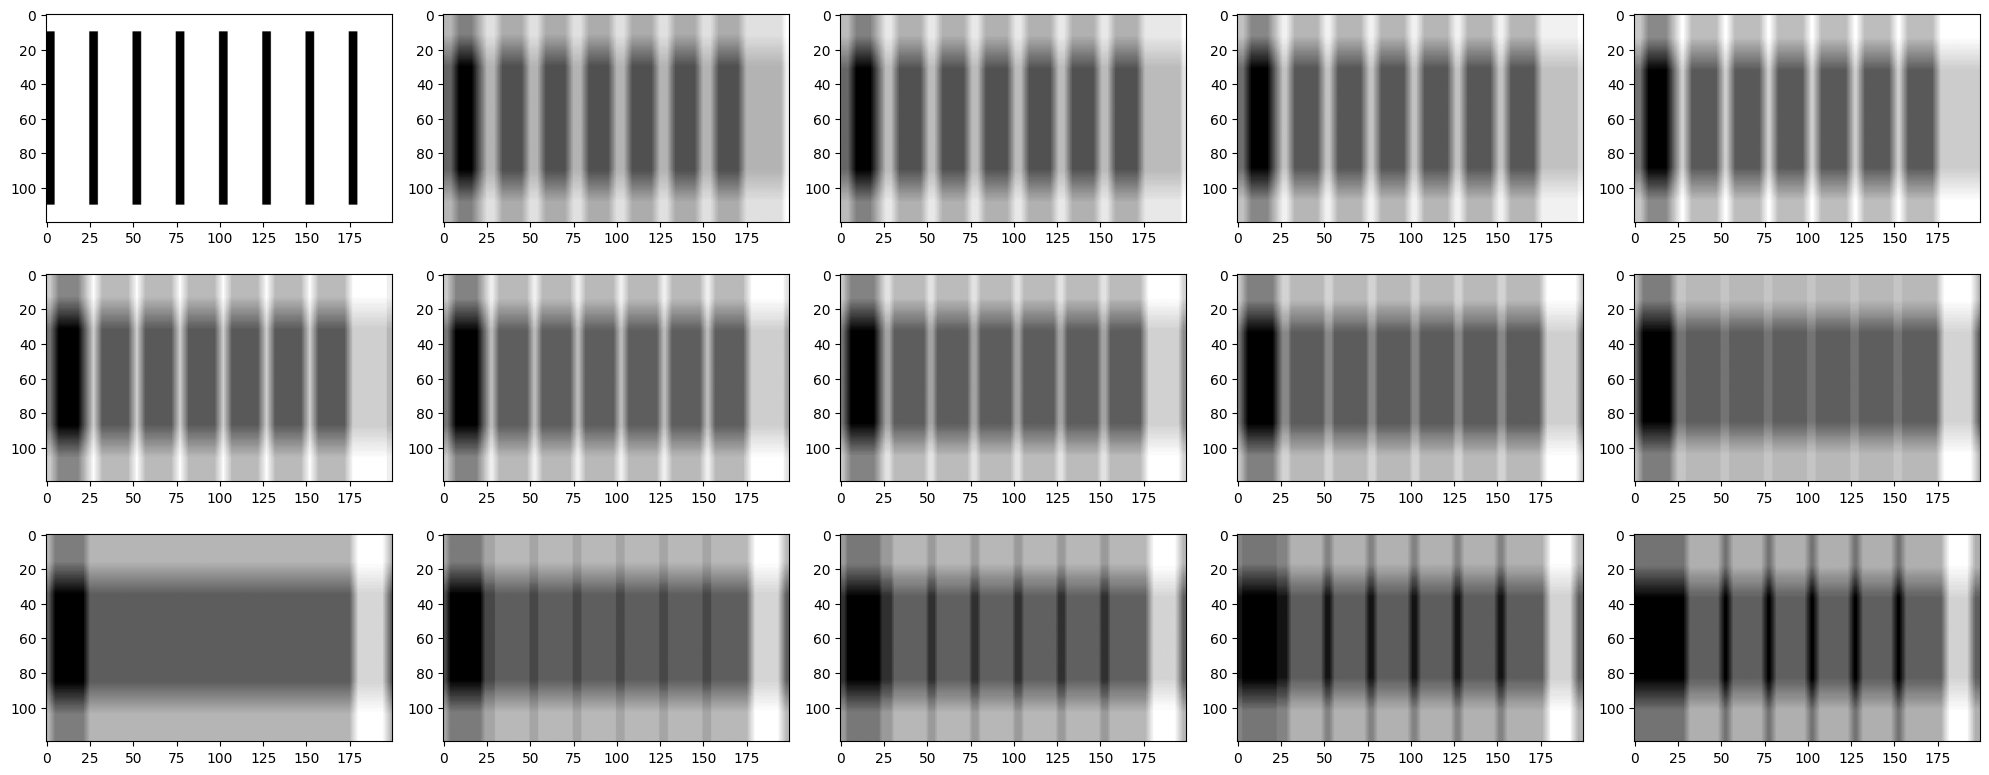

In [396]:
_, axs = plt.subplots(3, 5, figsize=(20,8))
axs = axs.flatten()
axs = axs.flatten()
_ims(axs[0], img)
for i in range(1, len(axs)):
    _ims(axs[i], _blur(40 + i))
plt.tight_layout()
plt.show()

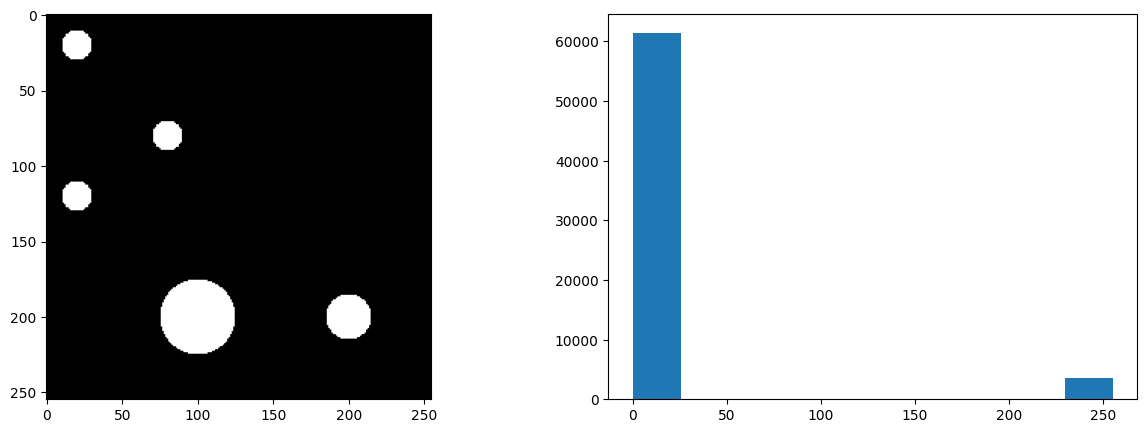

In [ ]:
from skimage import draw

img = np.zeros((255,255), dtype=np.uint8)

img[draw.disk((20,20), 10)] = 255
img[draw.disk((80,80), 10)] = 255

img[draw.disk((200,100), 25)] = 255

img[draw.disk((120,20), 10)] = 255
img[draw.disk((200,200), 15)] = 255


_, ax = plt.subplots(1, 2, figsize=(15,5))
ax[0].imshow(img, cmap="gray")
ax[1].hist(img.flatten())
plt.show()

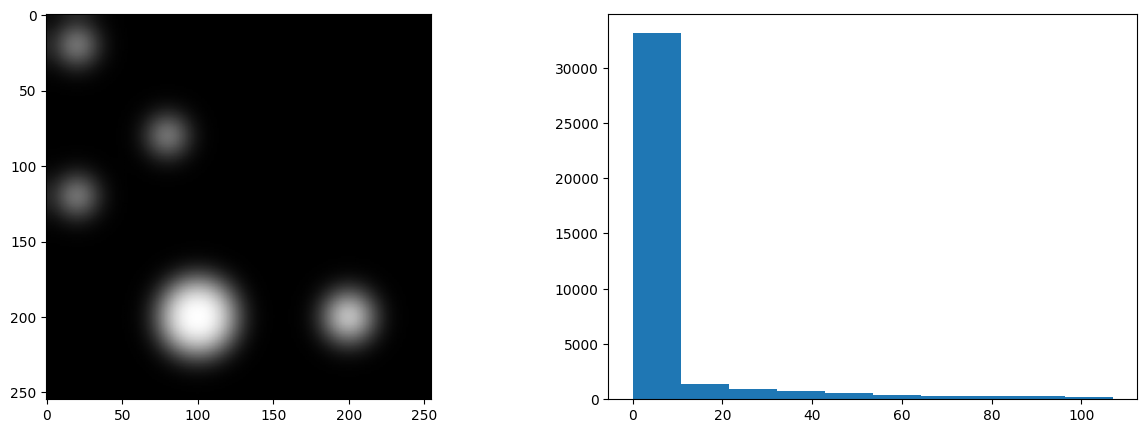

In [463]:
# blurred = cv2.blur(img, (
blurred = cv2.GaussianBlur(img, (61,61), 0)

_, ax = plt.subplots(1, 2, figsize=(15,5))
ax[0].imshow(blurred, cmap="gray")
ax[1].hist(blurred[:150].flatten())
plt.show()

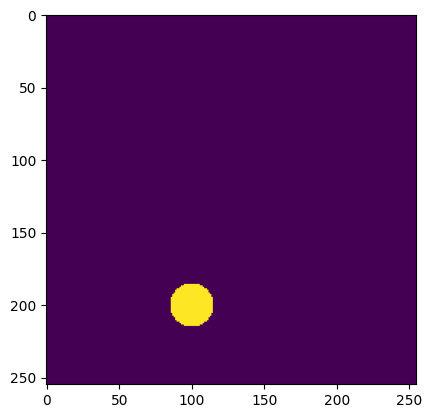

In [468]:
plt.imshow(blurred > 200)

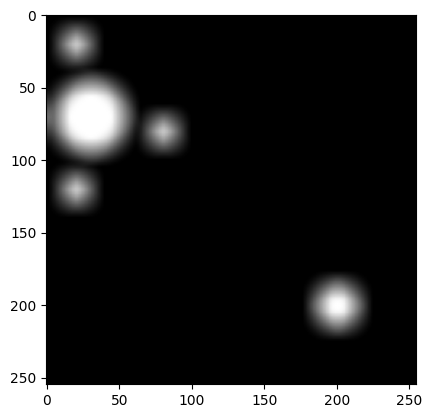

In [429]:
plt.imshow(blurred, cmap="gray")

# Plot unit circle

In [499]:
xs = np.linspace(0, 2 * np.pi)
s1 = np.sin(xs)
s2 = np.sin(2*xs)
s3 = np.sin(3*xs)

c1 = np.cos(xs)
c2 = np.cos(2*xs)
c3 = np.cos(3*xs)


def sums_till(n, xs):
    if n <= 0:
        raise Exception("n should be > 0 strictly")

    sins = [np.sin(i*xs) for i in range(1, n+1)]
    coses = [np.cos(i*xs) for i in range(1, n+1)]

    rsins = [sins[0]]
    rcoss = [coses[0]]

    for i in range(1, n):
        last_sin, last_cos = rsins[-1], rcoss[-1]
        rsins.append(last_sin + sins[i])
        rcoss.append(last_cos + coses[i])

    return rsins, rcoss

In [524]:
rsins, rcoses = sums_till(500, xs)

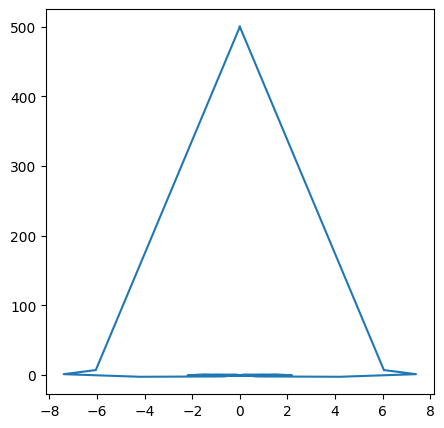

In [531]:
_, ax = plt.subplots(1, 1, figsize=(5,5))
# ax.set_aspect('equal', adjustable='box') # 'box' ensures the plot box is adjusted
# ax.plot(rsins[-1], np.clip(rcoses[-1], -1, 0))
ax.plot(rsins[-1], rcoses[-1])
plt.show()

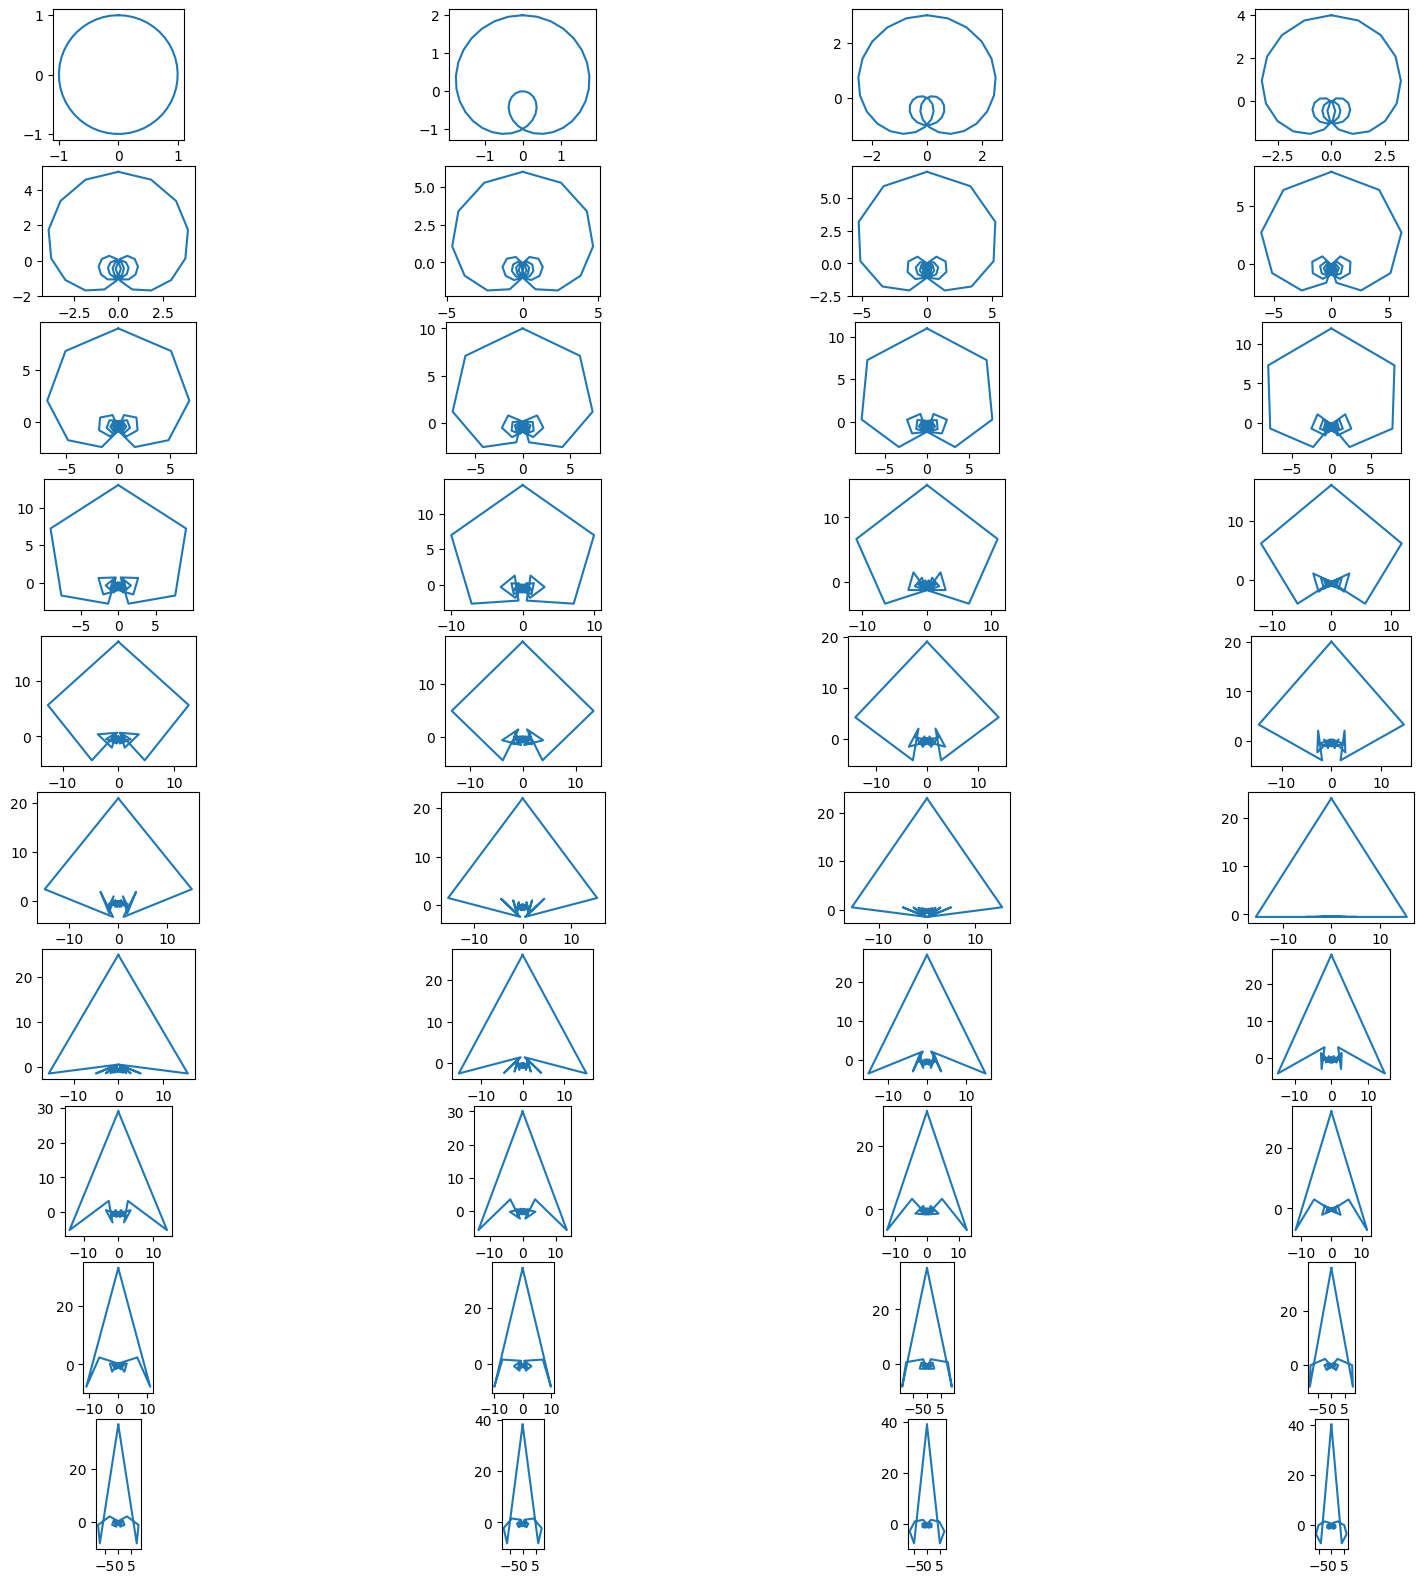

In [510]:
K = 40


rsins, rcoses = sums_till(K, xs)

nrows = np.ceil(K // 4)
ncols = 4
_, ax = plt.subplots(nrows, ncols, figsize=(20,20))
ax = ax.flatten()

for a in ax:
    a.set_aspect('equal', adjustable='box') # 'box' ensures the plot box is adjusted

for sin, cos, a in zip(rsins, rcoses, ax):
    a.plot(sin, cos)
plt.show()

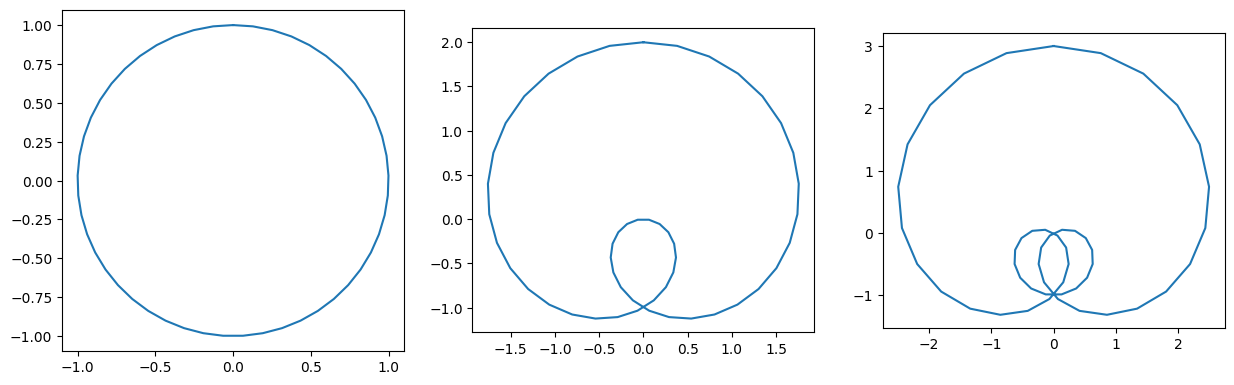

In [500]:
_, ax = plt.subplots(1, 3, figsize=(15,15))
for a in ax:
    a.set_aspect('equal', adjustable='box') # 'box' ensures the plot box is adjusted
ax[0].plot(s1, c1)
ax[1].plot(s1 + s2, c1 + c2)
ax[2].plot(s1 + s2 + s3, c1 + c2 + c3)
plt.show()